In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# load dataset
df=pd.read_csv(r"D:\researrch\agree.culture.Ai\code\dataset\Fertilizer Prediction.csv")
df

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea
...,...,...,...,...,...,...,...,...,...
94,25,50,32,Clayey,Pulses,24,0,19,28-28
95,30,60,27,Red,Tobacco,4,17,17,10-26-26
96,38,72,51,Loamy,Wheat,39,0,0,Urea
97,36,60,43,Sandy,Millets,15,0,41,DAP


In [ ]:
X=df.drop("Fertilizer Name",axis=1)
y=df["Fertilizer Name"]
# print(X)
# print(Y)
categorical_features=["Soil Type","Crop Type"]
numerical_features = ['Nitrogen', 'Phosphorous', 'Potassium', 'Temparature', 'Moisture']

preprocessor = ColumnTransformer(
    transformers=[
                ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])







# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded, test_size=0.3, random_state=42)

# Create a pipeline with preprocessing and a RandomForestClassifier
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


import joblib
joblib.dump(model_pipeline, 'fertilizer_prediction_model.pkl')
joblib.dump(label_encoder, 'fertilizer_label_encoder.pkl')

print("\nModel and label encoder saved as 'fertilizer_prediction_model.pkl' and 'fertilizer_label_encoder.pkl'.")
print("You can now load these to make new predictions, for example, in a chatbot interface.")

NameError: name 'y_encoded' is not defined

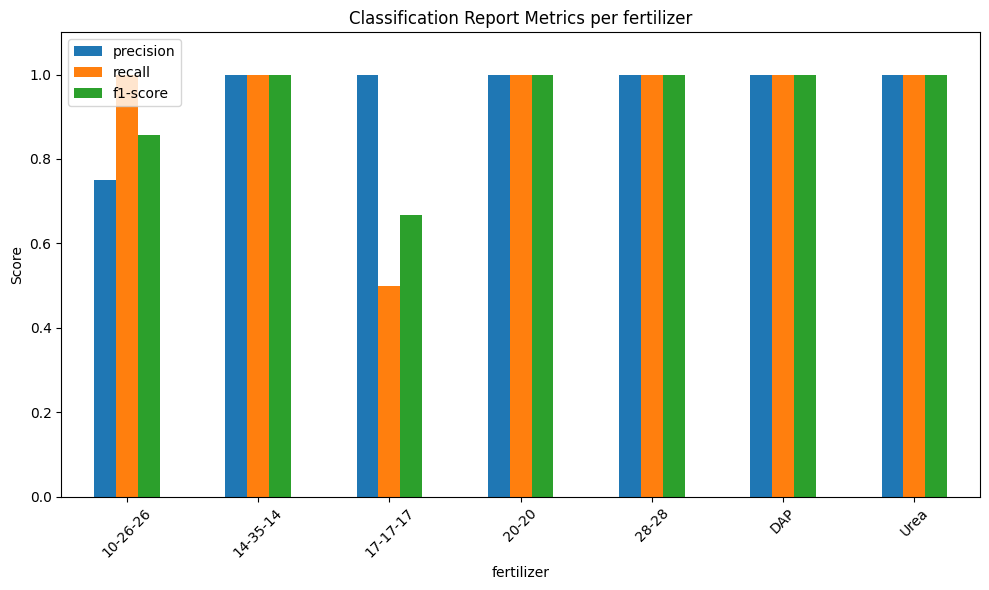

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Get classification report as a dictionary
report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)

# Convert to DataFrame for easier plotting, excluding 'accuracy', 'macro avg', 'weighted avg'
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.drop(columns=['support'])

# Filter out aggregate rows for plotting individual class metrics
df_report_classes = df_report.loc[label_encoder.classes_]

# Plotting the classification report
fig, ax = plt.subplots(figsize=(10, 6))
df_report_classes.plot(kind='bar', ax=ax)
ax.set_title('Classification Report Metrics per fertilizer')
ax.set_ylabel('Score')
ax.set_xlabel('fertilizer')
ax.set_ylim(0, 1.1) # Set y-limit to clearly show scores between 0 and 1
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()